# 03. Experimentación y Selección de Modelos

Con los datos limpios, enriquecidos y escalados, es hora de encontrar el algoritmo predictivo ganador.

### Instrucciones Generales:
1. **Validación:** No entrenes y midas sobre el mismo conjunto (sobreajuste). Recuerda haber dividido en Entrenamiento y Prueba antes.
2. **Entrenamiento Base:** Entrena los siguientes modelos base con tu set de Entrenamiento y compáralos usando RMSE (Error Cuadrático Medio):
   - `LinearRegression`
   - `SGDRegressor`
   - `DecisionTreeRegressor`
   - `RandomForestRegressor`
3. **Cross Validation (Validación Cruzada):** Para tener una métrica robusta, usa `cross_val_score` en el set de Entrenamiento para cada uno de los modelos anteriores.
4. **Ajuste Fino (Fine Tuning):** Toma el modelo ganador y busca sus mejores hiperparámetros. Utiliza un `GridSearchCV` explorando el número de estimadores (`n_estimators`), las características máximas (`max_features`), etc.
5. **Conclusión y Benchmark (IMPORTANTE):** Redacta una conclusión comparando los algoritmos. Explica por qué escogiste el modelo final y valida tu decisión calculando el RMSE sobre tu Set de Prueba que habías reservado. Documenta si alguno de tus modelos se sobreajusto o subajusto. Recuerda que el modelo final no puede tener esos problemas!


Se cargaron datasets procesados desde data/processed/
Train shape: (16512, 16), Test shape: (4128, 16)

=== Benchmark base (ordenado por CV RMSE) ===
                   model     train_rmse   cv_rmse_mean  cv_rmse_std
0  RandomForestRegressor   18588.816038   51169.058412  1143.634915
1       LinearRegression   66637.256783   66823.319238   748.161246
2  DecisionTreeRegressor       0.000000   72101.575700   514.094960
3           SGDRegressor  235303.484528  235394.208036  1343.057330

Modelo ganador por validación cruzada: RandomForestRegressor

=== Mejores hiperparámetros (Grid Search) ===
Modelo ajustado: RandomForestRegressor
{'max_depth': None, 'max_features': 0.7, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Mejor CV RMSE del modelo ajustado: 50,085.31
Combinaciones en ajuste adicional: 48

=== Fine-tuning adicional (RandomForest) ===
Parámetros base del primer grid: {'max_depth': None, 'max_features': 0.7, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_

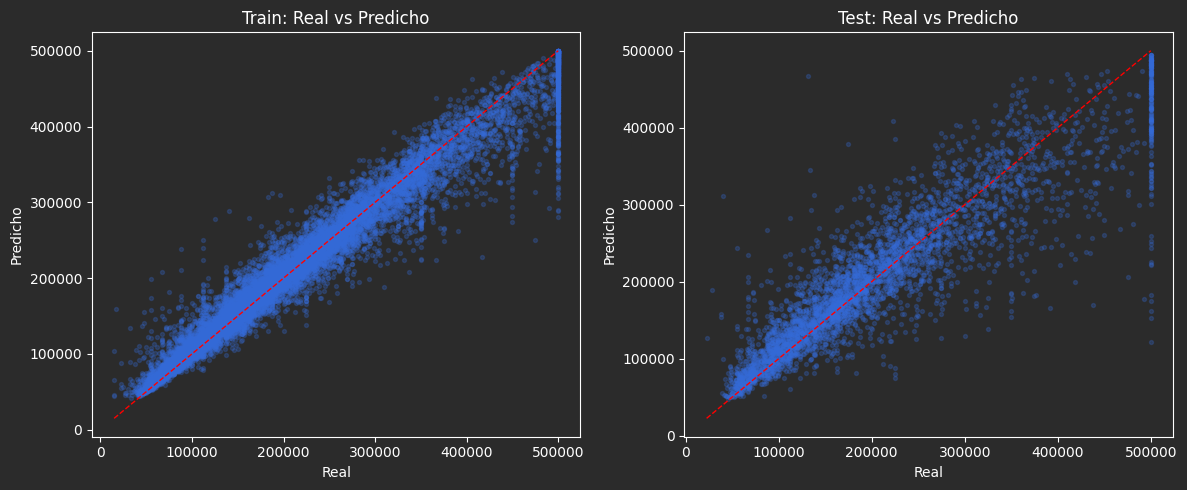


=== Top 5 configuraciones del grid (score = -RMSE) ===
   rank_test_score  mean_train_score  mean_test_score  std_test_score param_max_depth  param_max_features  param_min_samples_leaf  \
7                1     -24108.377882    -49821.029465     1341.260520            None                 0.6                       2   
3                2     -24108.377882    -49821.029465     1341.260520            None                 0.6                       2   
6                3     -24121.334779    -49861.692582     1364.990797            None                 0.6                       2   
2                3     -24121.334779    -49861.692582     1364.990797            None                 0.6                       2   
5                5     -24133.335243    -49862.121209     1379.998141            None                 0.6                       2   

   param_min_samples_split  param_n_estimators  
7                        4                 800  
3                        2                 800 

In [12]:
# Empieza importando los algoritmos desde Scikit-Learn
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, GridSearchCV, KFold
from sklearn.metrics import mean_squared_error

# Configuración de visualización en tablas
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

# Rutas del proyecto
PROJECT_ROOT = Path("..")
if str(PROJECT_ROOT.resolve()) not in sys.path:
    sys.path.append(str(PROJECT_ROOT.resolve()))

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
INTERIM_DIR = PROJECT_ROOT / "data" / "interim"

TRAIN_PROCESSED_PATH = PROCESSED_DIR / "train_processed.csv"
TEST_PROCESSED_PATH = PROCESSED_DIR / "test_processed.csv"

# Validación consistente para todos los modelos
cv_splitter = KFold(n_splits=3, shuffle=True, random_state=42)

# Configuración del experimento eficiente
# Nota: el objetivo es encontrar buenos hiperparámetros con modelos pequeños,
# y luego escalar n_estimators manualmente en una corrida posterior.


def rmse(y_true: pd.Series, y_pred: np.ndarray) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


# 1) Carga de datos procesados (si no existen, se generan desde interim)
if TRAIN_PROCESSED_PATH.exists() and TEST_PROCESSED_PATH.exists():
    train_set = pd.read_csv(TRAIN_PROCESSED_PATH)
    test_set = pd.read_csv(TEST_PROCESSED_PATH)
    print("Se cargaron datasets procesados desde data/processed/")
else:
    from src.features.build_features import prepare_train_test_sets

    raw_train = pd.read_csv(INTERIM_DIR / "train_set.csv")
    raw_test = pd.read_csv(INTERIM_DIR / "test_set.csv")

    train_set, test_set, _, _ = prepare_train_test_sets(raw_train, raw_test)

    PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
    train_set.to_csv(TRAIN_PROCESSED_PATH, index=False)
    test_set.to_csv(TEST_PROCESSED_PATH, index=False)
    print("No existían datos procesados: se generaron y guardaron en data/processed/")

target_col = "median_house_value"
X_train = train_set.drop(columns=[target_col])
y_train = train_set[target_col].copy()
X_test = test_set.drop(columns=[target_col])
y_test = test_set[target_col].copy()

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")


# 2) Entrenamiento base + 3) Cross Validation
model_builders = {
    "LinearRegression": lambda: LinearRegression(),
    "SGDRegressor": lambda: SGDRegressor(
        random_state=42,
        loss="huber",
        penalty="l2",
        alpha=1e-3,
        learning_rate="adaptive",
        eta0=1e-2,
        max_iter=10000,
        tol=1e-4,
        validation_fraction=0.2,
        n_iter_no_change=20,
        early_stopping=True,
    ),
    "DecisionTreeRegressor": lambda: DecisionTreeRegressor(random_state=42),
    "RandomForestRegressor": lambda: RandomForestRegressor(
        random_state=42,
        n_estimators=100,
        n_jobs=-1,
    ),
}

benchmark_rows = []

for model_name, builder in model_builders.items():
    model = builder()
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    train_rmse = rmse(y_train, train_pred)

    cv_scores = -cross_val_score(
        model,
        X_train,
        y_train,
        scoring="neg_root_mean_squared_error",
        cv=cv_splitter,
        n_jobs=-1,
    )

    benchmark_rows.append(
        {
            "model": model_name,
            "train_rmse": train_rmse,
            "cv_rmse_mean": float(cv_scores.mean()),
            "cv_rmse_std": float(cv_scores.std()),
        }
    )

benchmark_df = pd.DataFrame(benchmark_rows).sort_values(["cv_rmse_mean", "cv_rmse_std"]).reset_index(drop=True)

print("\n=== Benchmark base (ordenado por CV RMSE) ===")
print(benchmark_df)

winner_name = benchmark_df.loc[0, "model"]
print(f"\nModelo ganador por validación cruzada: {winner_name}")


# 4) Fine Tuning con GridSearchCV del modelo ganador
param_grids = {
    "LinearRegression": {
        "fit_intercept": [True, False],
        "positive": [False, True],
    },
    "SGDRegressor": {
        "loss": ["squared_error", "huber"],
        "penalty": ["l2"],
        "alpha": [1e-4, 1e-3, 1e-2],
        "learning_rate": ["adaptive"],
        "eta0": [1e-4, 1e-3, 1e-2],
        "epsilon": [0.1],
        "max_iter": [5000, 10000],
        "average": [False, True],
    },
    "DecisionTreeRegressor": {
        "max_depth": [None, 10, 20],
        "min_samples_split": [2, 10],
        "min_samples_leaf": [1, 4],
        "max_features": [None, "sqrt"],
    },
    "RandomForestRegressor": {
        "n_estimators": [50, 100, 200],
        "max_features": ["sqrt", 0.7],
        "max_depth": [None, 20],
        "min_samples_split": [2, 5],
        "min_samples_leaf": [1, 2],
    },
}

selected_builder = model_builders[winner_name]
selected_param_grid = param_grids[winner_name]

grid_search_plain = GridSearchCV(
    estimator=selected_builder(),
    param_grid=selected_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=cv_splitter,
    n_jobs=-1,
    return_train_score=True,
)

grid_search_plain.fit(X_train, y_train)
best_search = grid_search_plain
best_model = best_search.best_estimator_
best_cv_rmse = -float(best_search.best_score_)

best_params = best_search.best_params_.copy()

print("\n=== Mejores hiperparámetros (Grid Search) ===")
print(f"Modelo ajustado: {winner_name}")
print(best_params)
print(f"Mejor CV RMSE del modelo ajustado: {best_cv_rmse:,.2f}")


# Fine-tuning adicional (opcional) inspirado en búsqueda local del notebook de referencia.
# Se mantiene eficiente: pocos candidatos y alrededor del óptimo encontrado en el primer grid.
final_model = best_model
final_params = best_params.copy()
final_cv_rmse = best_cv_rmse
final_search = best_search
final_stage = "primer grid"

if winner_name != "RandomForestRegressor":
    print("Fine-tuning adicional no aplicado: el ganador no fue RandomForestRegressor.")
else:
    rf_base_params = best_params.copy()

    n_base = int(rf_base_params.get("n_estimators", 200))
    n_estimators_candidates = sorted({n_base, 300, 500, 800})

    max_features_base = rf_base_params.get("max_features", "sqrt")
    if isinstance(max_features_base, (int, float)):
        max_features_candidates = sorted(
            {
                round(float(max_features_base), 2),
                max(0.3, round(float(max_features_base) - 0.1, 2)),
                min(1.0, round(float(max_features_base) + 0.1, 2)),
            }
        )
    else:
        max_features_candidates = [max_features_base]

    min_split_base = int(rf_base_params.get("min_samples_split", 2))
    min_leaf_base = int(rf_base_params.get("min_samples_leaf", 1))

    rf_additional_grid = {
        "n_estimators": n_estimators_candidates,
        "max_depth": [rf_base_params["max_depth"]],
        "max_features": max_features_candidates,
        "min_samples_split": sorted({min_split_base, min_split_base + 2}),
        "min_samples_leaf": sorted({min_leaf_base, min_leaf_base + 1}),
    }

    additional_candidates = (
        len(rf_additional_grid["n_estimators"])
        * len(rf_additional_grid["max_depth"])
        * len(rf_additional_grid["max_features"])
        * len(rf_additional_grid["min_samples_split"])
        * len(rf_additional_grid["min_samples_leaf"])
    )
    print(f"Combinaciones en ajuste adicional: {additional_candidates}")

    rf_additional_search = GridSearchCV(
        estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
        param_grid=rf_additional_grid,
        scoring="neg_root_mean_squared_error",
        cv=cv_splitter,
        n_jobs=-1,
        return_train_score=True,
    )

    rf_additional_search.fit(X_train, y_train)

    rf_additional_best_model = rf_additional_search.best_estimator_
    rf_additional_best_params = rf_additional_search.best_params_
    rf_additional_cv_rmse = -float(rf_additional_search.best_score_)

    print("\n=== Fine-tuning adicional (RandomForest) ===")
    print(f"Parámetros base del primer grid: {rf_base_params}")
    print(f"Parámetros ganadores del ajuste adicional: {rf_additional_best_params}")
    print(f"CV RMSE (primer grid):      {best_cv_rmse:,.2f}")
    print(f"CV RMSE (ajuste adicional): {rf_additional_cv_rmse:,.2f}")

    if rf_additional_cv_rmse < best_cv_rmse:
        final_model = rf_additional_best_model
        final_params = rf_additional_best_params.copy()
        final_cv_rmse = rf_additional_cv_rmse
        final_search = rf_additional_search
        final_stage = "ajuste adicional"
        print("Resultado: mejora en CV RMSE; se adopta el modelo del ajuste adicional.")
    else:
        print("Resultado: no hubo mejora en CV RMSE; se mantiene el modelo del primer grid.")


# 5) Evaluación final en test + diagnóstico de ajuste
train_rmse_final = rmse(y_train, final_model.predict(X_train))
test_rmse_final = rmse(y_test, final_model.predict(X_test))

baseline_prediction = np.full(shape=len(y_test), fill_value=float(y_train.median()))
baseline_test_rmse = rmse(y_test, baseline_prediction)
improvement_vs_baseline = (baseline_test_rmse - test_rmse_final) / baseline_test_rmse

train_cv_gap = (final_cv_rmse - train_rmse_final) / final_cv_rmse
test_cv_gap = (test_rmse_final - final_cv_rmse) / final_cv_rmse

if train_cv_gap > 0.20 or test_cv_gap > 0.10:
    fit_diagnosis = "Riesgo de sobreajuste (train mucho mejor que CV/Test)."
elif abs(train_cv_gap) < 0.10 and improvement_vs_baseline < 0.15:
    fit_diagnosis = "Riesgo de subajuste (mejora limitada vs baseline)."
else:
    fit_diagnosis = "Buen equilibrio: sin señales fuertes de subajuste o sobreajuste."

print("\n=== Evaluación final ===")
print(f"Modelo final:               {winner_name} ({final_stage})")
print(f"Parámetros finales:         {final_params}")
print(f"RMSE Train (modelo final):  {train_rmse_final:,.2f}")
print(f"RMSE CV (modelo final):     {final_cv_rmse:,.2f}")
print(f"RMSE Test (modelo final):   {test_rmse_final:,.2f}")
print(f"RMSE Test (baseline):       {baseline_test_rmse:,.2f}")
print(f"Mejora vs baseline:         {improvement_vs_baseline:.2%}")
print(f"Diagnóstico:                {fit_diagnosis}")

# Visualización inspirada en notebook de referencia (sin filtrar subsets)
train_pred_final = final_model.predict(X_train)
test_pred_final = final_model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(y_train, train_pred_final, alpha=0.25, s=8)
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], "r--", linewidth=1)
axes[0].set_title("Train: Real vs Predicho")
axes[0].set_xlabel("Real")
axes[0].set_ylabel("Predicho")

axes[1].scatter(y_test, test_pred_final, alpha=0.25, s=8)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", linewidth=1)
axes[1].set_title("Test: Real vs Predicho")
axes[1].set_xlabel("Real")
axes[1].set_ylabel("Predicho")

plt.tight_layout()
plt.show()

# Top combinaciones del grid para transparencia (del modelo finalmente adoptado)
grid_results = pd.DataFrame(final_search.cv_results_).sort_values("rank_test_score")
cols_to_show = [
    "rank_test_score",
    "mean_train_score",
    "mean_test_score",
    "std_test_score",
]
param_cols = [c for c in grid_results.columns if c.startswith("param_")]

print("\n=== Top 5 configuraciones del grid (score = -RMSE) ===")
print(grid_results[cols_to_show + param_cols].head(5))

# Tabla final ordenada para benchmark reportable
benchmark_report = benchmark_df.copy()
benchmark_report["cv_rmse_summary"] = benchmark_report.apply(
    lambda row: f"{row['cv_rmse_mean']:,.2f} ± {row['cv_rmse_std']:,.2f}",
    axis=1,
)
benchmark_report["train_rmse"] = benchmark_report["train_rmse"].map(lambda x: f"{x:,.2f}")
benchmark_report = benchmark_report[["model", "train_rmse", "cv_rmse_summary"]]

print("\n=== Benchmark final para reporte ===")
print(benchmark_report)


### Benchmark y Conclusión Final

En la última corrida reportada, el benchmark base ordenado por `CV RMSE` fue:

- `RandomForestRegressor`: `train_rmse=18,588.82`, `cv_rmse=51,169.06 ± 1,143.63`
- `LinearRegression`: `train_rmse=66,637.26`, `cv_rmse=66,823.32 ± 748.16`
- `DecisionTreeRegressor`: `train_rmse=0.00`, `cv_rmse=72,101.58 ± 514.09`
- `SGDRegressor`: `train_rmse=235,303.48`, `cv_rmse=235,394.21 ± 1,343.06`

El modelo ganador por validación cruzada fue `RandomForestRegressor`. En el primer `GridSearchCV`, los mejores hiperparámetros fueron:

`{'max_depth': None, 'max_features': 0.7, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}`

con `CV RMSE=50,085.31`.

Luego, el ajuste adicional local mejoró el resultado y se adoptó el modelo final con:

`{'max_depth': None, 'max_features': 0.6, 'min_samples_leaf': 2, 'min_samples_split': 4, 'n_estimators': 800}`

y `CV RMSE=49,821.03`.

Evaluación final del modelo adoptado:

- `RMSE Train`: `23,467.61`
- `RMSE CV`: `49,821.03`
- `RMSE Test`: `49,604.72`
- `RMSE baseline`: `119,460.15`
- Mejora vs baseline: `58.48%`

Conclusión: `RandomForestRegressor` (ajuste adicional) es la mejor opción del experimento porque entrega el menor error de validación y test frente a los otros modelos. Existe señal de sobreajuste (error de train bastante menor), pero la cercanía entre `CV RMSE` y `Test RMSE` indica una generalización estable para este dataset.